In [1]:
# !pip install transformers torch supervision
# !huggingface-cli login   # ejecuta esto una vez para autenticarte

import supervision as sv
from transformers import Sam3Processor, Sam3Model
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import urllib.request
from pathlib import Path
from PIL import Image

Path("assets/fotos").mkdir(exist_ok=True)
urllib.request.urlretrieve("https://ultralytics.com/images/bus.jpg", "assets/fotos/bus.jpg")
urllib.request.urlretrieve("https://ultralytics.com/images/zidane.jpg", "assets/fotos/zidane.jpg")

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo: {device}")
# En CPU SAM 3 es lento (~30–60 s por imagen); en GPU es fluido.


Dispositivo: cpu


In [2]:
# El processor convierte imágenes y prompts al formato que el modelo espera
# El model es la red neuronal que genera las máscaras
processor = Sam3Processor.from_pretrained("facebook/sam3")
model     = Sam3Model.from_pretrained("facebook/sam3").to(device)
model.eval()   # desactivar dropout y otras capas de entrenamiento

print("Modelo cargado")
print(f"Parámetros: {sum(p.numel() for p in model.parameters()) / 1e6:.0f} M")


Loading weights:   0%|          | 0/1468 [00:00<?, ?it/s]

Modelo cargado
Parámetros: 840 M


In [3]:
# Función auxiliar: convierte el output de transformers a sv.Detections
def sam3_a_detections(results: dict) -> sv.Detections:
    masks  = results["masks"].cpu().numpy().astype(bool)   # (N, H, W)
    xyxy   = results["boxes"].cpu().numpy()                 # (N, 4) formato x1y1x2y2
    scores = results["scores"].cpu().numpy()                # (N,)
    return sv.Detections(xyxy=xyxy, mask=masks, confidence=scores)


# Cargar imagen como PIL (transformers usa PIL, OpenCV usa BGR)
image_pil = Image.open("assets/fotos/bus.jpg").convert("RGB")
image_bgr = cv2.imread("assets/fotos/bus.jpg")   # solo para anotar con Supervision

# Preparar inputs: imagen + texto
inputs = processor(
    images=image_pil,
    text="person",
    return_tensors="pt"
).to(device)

# Inferencia sin gradientes (más rápido, menos memoria)
with torch.no_grad():
    outputs = model(**inputs)

# Post-procesado: convierte tensores brutos a máscaras binarias y cajas
results = processor.post_process_instance_segmentation(
    outputs,
    threshold=0.5,
    mask_threshold=0.5,
    target_sizes=[image_pil.size[::-1]]   # (alto, ancho)
)[0]

detections = sam3_a_detections(results)

print(f"Objetos encontrados: {len(detections)}")
print(f"¿Tiene máscaras?    {detections.mask is not None}")
if detections.mask is not None:
    print(f"Shape de máscaras:  {detections.mask.shape}")


Objetos encontrados: 4
¿Tiene máscaras?    True
Shape de máscaras:  (4, 1080, 810)


In [4]:
print("Claves del output post-procesado:", list(results.keys()))
print()
print(f"masks  → tipo: {type(results['masks'])},  shape: {results['masks'].shape}")
print(f"boxes  → tipo: {type(results['boxes'])},  shape: {results['boxes'].shape}")
print(f"scores → tipo: {type(results['scores'])}, shape: {results['scores'].shape}")
print()
print("Después de sam3_a_detections():")
print(f"  xyxy:       {detections.xyxy.shape}")
print(f"  mask:       {detections.mask.shape}")
print(f"  confidence: {detections.confidence}")
# La conversión es: tensor GPU → numpy CPU → sv.Detections
# Eso es todo lo que necesita Supervision para trabajar con el resultado.


Claves del output post-procesado: ['scores', 'boxes', 'masks']

masks  → tipo: <class 'torch.Tensor'>,  shape: torch.Size([4, 1080, 810])
boxes  → tipo: <class 'torch.Tensor'>,  shape: torch.Size([4, 4])
scores → tipo: <class 'torch.Tensor'>, shape: torch.Size([4])

Después de sam3_a_detections():
  xyxy:       (4, 4)
  mask:       (4, 1080, 810)
  confidence: [0.9657164  0.95125073 0.97732687 0.97537893]


Objetos con ['person', 'bus']: 4


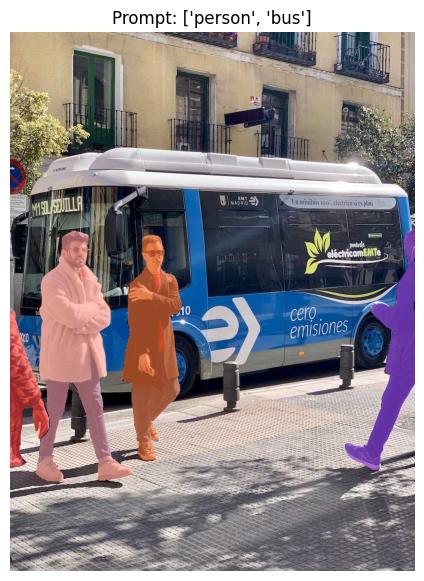

In [5]:
# Segmentar 'person' y 'bus' en la misma imagen
inputs_multi = processor(
    images=image_pil,
    text=[["person", "bus"]],   # lista de conceptos
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs_multi = model(**inputs_multi)

results_multi = processor.post_process_instance_segmentation(
    outputs_multi,
    threshold=0.5,
    mask_threshold=0.5,
    target_sizes=[image_pil.size[::-1]]
)[0]

det_multi = sam3_a_detections(results_multi)
print(f"Objetos con ['person', 'bus']: {len(det_multi)}")

annotated_multi = sv.MaskAnnotator(opacity=0.6).annotate(
    scene=image_bgr.copy(), 
    detections=det_multi, 
    custom_color_lookup= sv.ColorLookup.INDEX
)
plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated_multi, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Prompt: ['person', 'bus']")
plt.show()
# 💭 Reflexión: ¿El modelo segmenta los dos conceptos por separado o juntos?
# Juntos — devuelve todas las instancias de ambos conceptos en el mismo resultado.


In [ ]:
from ultralytics import YOLO

# Obtener cajas con YOLO
yolo_model  = YOLO("yolov8n.pt")
yolo_r      = yolo_model(image_bgr)[0]
yolo_det    = sv.Detections.from_ultralytics(yolo_r)
solo_person = yolo_det[yolo_det.class_id == 0]   # clase 0 = person

# SAM 3 con bounding boxes de YOLO
boxes_list = solo_person.xyxy.tolist()
inputs_bbox = processor(
    images=image_pil,
    input_boxes=[[b] for b in boxes_list],     # una caja por llamada
    input_boxes_labels=[[1]] * len(boxes_list),
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs_bbox = model(**inputs_bbox)

results_bbox = processor.post_process_instance_segmentation(
    outputs_bbox,
    threshold=0.5,
    mask_threshold=0.5,
    target_sizes=[image_pil.size[::-1]]
)[0]
det_bbox = sam3_a_detections(results_bbox)

# Comparar lado a lado
scene_txt  = sv.MaskAnnotator(opacity=0.6).annotate(scene=image_bgr.copy(), detections=detections)
scene_bbox = sv.MaskAnnotator(opacity=0.6).annotate(scene=image_bgr.copy(), detections=det_bbox)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
ax1.imshow(cv2.cvtColor(scene_txt,  cv2.COLOR_BGR2RGB)); ax1.set_title('Prompt texto: "person"');  ax1.axis("off")
ax2.imshow(cv2.cvtColor(scene_bbox, cv2.COLOR_BGR2RGB)); ax2.set_title("Prompt bbox (YOLO)");      ax2.axis("off")
plt.suptitle("Texto vs. bounding box — ¿producen las mismas máscaras?", fontsize=13)
plt.tight_layout()
plt.show()
# 💭 Reflexión: ¿Cuándo preferirías uno sobre el otro?
# Texto: no necesitas un detector previo, útil cuando empiezas desde cero.
# Bbox: más preciso cuando ya tienes un detector entrenado para tu dominio.



0: 640x480 4 persons, 1 bus, 1 stop sign, 142.7ms
Speed: 3.1ms preprocess, 142.7ms inference, 10.1ms postprocess per image at shape (1, 3, 640, 480)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, thr in zip(axes, [0.2, 0.5, 0.8]):
    res_thr = processor.post_process_instance_segmentation(
        outputs,
        threshold=thr,
        mask_threshold=0.5,
        target_sizes=[image_pil.size[::-1]]
    )[0]
    det_thr = sam3_a_detections(res_thr)
    scene   = sv.MaskAnnotator(opacity=0.6).annotate(scene=image_bgr.copy(), detections=det_thr)
    ax.imshow(cv2.cvtColor(scene, cv2.COLOR_BGR2RGB))
    ax.set_title(f"threshold={thr}  ({len(det_thr)} objetos)")
    ax.axis("off")

plt.tight_layout()
plt.show()
# 💭 Reflexión: ¿Qué threshold usarías en producción?
# Depende del caso: alta precisión (manufactura) → umbral alto.
# Alta cobertura (seguridad) → umbral bajo y filtrado posterior.

In [ ]:
processor = Sam3Processor.from_pretrained("facebook/sam3")
model     = Sam3Model.from_pretrained("facebook/sam3").to(device)
model.eval()
def segmentar_con_texto(ruta_imagen: str, texto: str, umbral: float = 0.5) -> sv.Detections:
    image_pil = Image.open(ruta_imagen).convert("RGB")
    inputs = processor(
        images=image_pil,
        text='face',
        return_tensors='pt'
    ).to(device)
    outputs = model(**inputs)
    results = processor.post_process_instance_segmentation(
        outputs=outputs,
        threshold=0.5,
        mask_threshold=0.5
    )
    return sam3_a_detections(results=results)
    pass


det = segmentar_con_texto("assets/fotos/zidane.jpg", "face")
print(f"Rostros encontrados: {len(det)}")
